# M17 · Transformers (Decoder-only) — ✍️ Toy Example, Step by Tiny Step

**Companion to lesson M17. Written for someone new to ML.**

A **decoder-only Transformer** is the style of model used by GPT-like language models. It reads
token IDs, turns them into vectors, uses **masked self-attention** so each position can only look
left, runs a small **feed-forward network**, and predicts the **next token ID**.

Every section below is a clearly marked **Toy example** with tiny matrices, printed intermediate
values, a picture, and assertions that pin the important facts.

## Step 0 · Setup

Import NumPy (arrays and matrix math) and Matplotlib (pictures). Fix the seed so the same tiny
numbers appear every time, choose a small default figure size, and define `log(label, value)` for
readable printouts.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)

def log(label, value):
    print(f"[{label}] {value}")

def softmax(x, axis=-1):
    x = np.asarray(x, dtype=float)
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=axis, keepdims=True)

log("setup", "NumPy + Matplotlib ready, seed fixed to 0")

[setup] NumPy + Matplotlib ready, seed fixed to 0


## 1 · Tokens → embeddings — Toy example: a tiny lookup table

A **token** is a small piece of text, represented inside the model as an integer ID. An
**embedding** is a learned vector for one token ID. The first Transformer step is just a lookup:
pick the row of the embedding table for each token ID.

**Good for:** converting words/subwords into numbers a model can process.  
**Watch out for:** token IDs are not meanings by themselves; the vector rows carry the meaning.

[vocab word -> id] {'<bos>': 0, 'I': 1, 'like': 2, 'cats': 3, 'dogs': 4, '.': 5}
[embedding table E (6 words x 4 dims)] [[ 0.2   0.    0.1   0.3 ]
 [ 0.9   0.1  -0.2   0.  ]
 [ 0.1   0.8   0.2  -0.1 ]
 [-0.2   0.3   0.9   0.1 ]
 [-0.1   0.25  0.85 -0.2 ]
 [ 0.   -0.2   0.1   0.7 ]]
[sentence tokens] ['<bos>', 'I', 'like', 'cats']
[sentence token IDs] [0, 1, 2, 3]
[looked-up vectors X_tok] [[ 0.2  0.   0.1  0.3]
 [ 0.9  0.1 -0.2  0. ]
 [ 0.1  0.8  0.2 -0.1]
 [-0.2  0.3  0.9  0.1]]


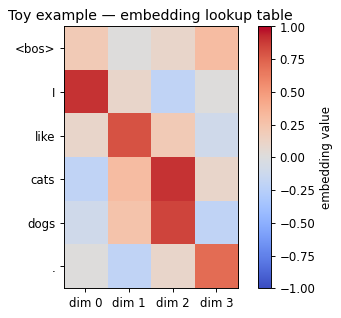

In [4]:
vocab = {"<bos>": 0, "I": 1, "like": 2, "cats": 3, "dogs": 4, ".": 5}
id_to_word = {i: w for w, i in vocab.items()}
E = np.array([
    [ 0.20,  0.00,  0.10,  0.30],   # <bos>
    [ 0.90,  0.10, -0.20,  0.00],   # I
    [ 0.10,  0.80,  0.20, -0.10],   # like
    [-0.20,  0.30,  0.90,  0.10],   # cats
    [-0.10,  0.25,  0.85, -0.20],   # dogs
    [ 0.00, -0.20,  0.10,  0.70],   # .
], dtype=float)

sentence = ["<bos>", "I", "like", "cats"]
ids = np.array([vocab[w] for w in sentence])
X_tok = E[ids]

log("vocab word -> id", vocab)
log("embedding table E (6 words x 4 dims)", np.round(E, 2))
log("sentence tokens", sentence)
log("sentence token IDs", ids.tolist())
log("looked-up vectors X_tok", np.round(X_tok, 2))
assert X_tok.shape == (4, 4)

plt.imshow(E, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Toy example — embedding lookup table")
plt.xticks(range(4), [f"dim {i}" for i in range(4)])
plt.yticks(range(len(vocab)), [id_to_word[i] for i in range(len(vocab))])
plt.colorbar(label="embedding value")
plt.show()

## Tokens → embeddings — Toy example: the same ID gets the same vector

An embedding table is deterministic: if token ID `3` means `"cats"`, every lookup of ID `3` returns
the same row before we add position information.

[repeat sentence] ['cats', 'cats', 'dogs', 'cats']
[repeat token IDs] [3, 3, 4, 3]
[looked-up vectors] [[-0.2   0.3   0.9   0.1 ]
 [-0.2   0.3   0.9   0.1 ]
 [-0.1   0.25  0.85 -0.2 ]
 [-0.2   0.3   0.9   0.1 ]]
[row 0 equals row 1 because both are 'cats'] True


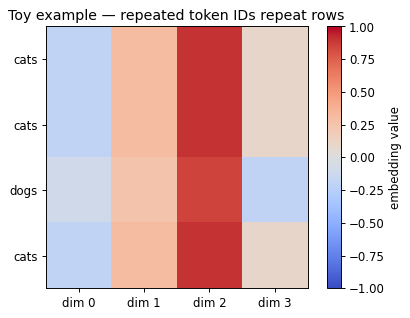

In [6]:
repeat_sentence = ["cats", "cats", "dogs", "cats"]
repeat_ids = np.array([vocab[w] for w in repeat_sentence])
repeat_X = E[repeat_ids]

log("repeat sentence", repeat_sentence)
log("repeat token IDs", repeat_ids.tolist())
log("looked-up vectors", np.round(repeat_X, 2))
log("row 0 equals row 1 because both are 'cats'", bool(np.allclose(repeat_X[0], repeat_X[1])))
assert np.allclose(repeat_X[0], repeat_X[1])

plt.imshow(repeat_X, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Toy example — repeated token IDs repeat rows")
plt.xticks(range(4), [f"dim {i}" for i in range(4)])
plt.yticks(range(len(repeat_sentence)), repeat_sentence)
plt.colorbar(label="embedding value")
plt.show()

## 2 · Self-attention from scratch — Toy example: Q, K, V

**Self-attention** lets each token mix information from other tokens in the same sequence. Each
token vector is projected into:

- **Q (query):** what this position is looking for.
- **K (key):** what this position offers for matching.
- **V (value):** the content this position will contribute if attended to.

The core formula is:

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)V$$

**Good for:** letting every position gather context from other positions.  
**Watch out for:** without a causal mask, a decoder can accidentally look at future tokens.

[trace tokens] ['I', 'like', 'cats']
[X input embeddings (3 x 4)] [[ 0.9  0.1 -0.2  0. ]
 [ 0.1  0.8  0.2 -0.1]
 [-0.2  0.3  0.9  0.1]]
[Wq] [[1.  0.  0.5 0. ]
 [0.  1.  0.  0.5]
 [0.5 0.  1.  0. ]
 [0.  0.5 0.  1. ]]
[Wk] [[0.8 0.1 0.  0.2]
 [0.1 0.9 0.2 0. ]
 [0.  0.2 0.9 0.1]
 [0.2 0.  0.1 0.8]]
[Wv] [[0.7 0.  0.2 0. ]
 [0.  0.6 0.  0.2]
 [0.2 0.  0.7 0. ]
 [0.  0.2 0.  0.6]]
[Q = X @ Wq] [[0.8  0.1  0.25 0.05]
 [0.2  0.75 0.25 0.3 ]
 [0.25 0.35 0.8  0.25]]
[K = X @ Wk] [[ 0.73  0.14 -0.16  0.16]
 [ 0.14  0.77  0.33 -0.04]
 [-0.11  0.43  0.88  0.13]]
[V = X @ Wv] [[0.59 0.06 0.04 0.02]
 [0.11 0.46 0.16 0.1 ]
 [0.04 0.2  0.59 0.12]]


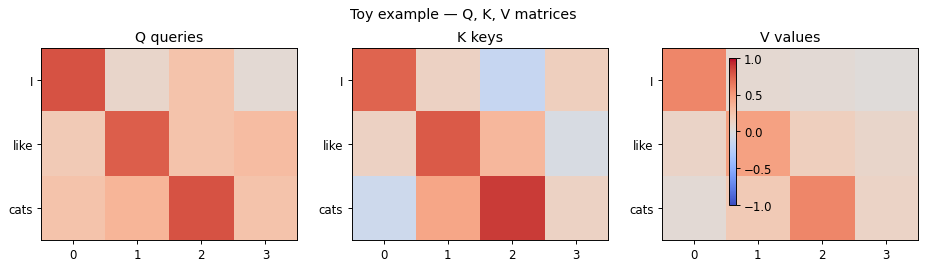

In [8]:
trace_tokens = ["I", "like", "cats"]
trace_ids = np.array([vocab[w] for w in trace_tokens])
X = E[trace_ids]                                  # T=3 tokens, d_model=4 dims
d_model = X.shape[1]

Wq = np.array([[1.0, 0.0, 0.5, 0.0],
               [0.0, 1.0, 0.0, 0.5],
               [0.5, 0.0, 1.0, 0.0],
               [0.0, 0.5, 0.0, 1.0]])
Wk = np.array([[0.8, 0.1, 0.0, 0.2],
               [0.1, 0.9, 0.2, 0.0],
               [0.0, 0.2, 0.9, 0.1],
               [0.2, 0.0, 0.1, 0.8]])
Wv = np.array([[0.7, 0.0, 0.2, 0.0],
               [0.0, 0.6, 0.0, 0.2],
               [0.2, 0.0, 0.7, 0.0],
               [0.0, 0.2, 0.0, 0.6]])

Q = X @ Wq
K = X @ Wk
V = X @ Wv

log("trace tokens", trace_tokens)
log("X input embeddings (3 x 4)", np.round(X, 2))
log("Wq", np.round(Wq, 2))
log("Wk", np.round(Wk, 2))
log("Wv", np.round(Wv, 2))
log("Q = X @ Wq", np.round(Q, 2))
log("K = X @ Wk", np.round(K, 2))
log("V = X @ Wv", np.round(V, 2))
assert Q.shape == K.shape == V.shape == (3, 4)

fig, ax = plt.subplots(1, 3, figsize=(11, 3))
for a, mat, title in zip(ax, [Q, K, V], ["Q queries", "K keys", "V values"]):
    im = a.imshow(mat, cmap="coolwarm", vmin=-1, vmax=1)
    a.set_title(title); a.set_xticks(range(4)); a.set_yticks(range(3)); a.set_yticklabels(trace_tokens)
fig.colorbar(im, ax=ax, shrink=0.75)
plt.suptitle("Toy example — Q, K, V matrices")
plt.tight_layout()
plt.show()

## Self-attention from scratch — Toy example: scores → softmax weights → output

The score between token *i* and token *j* is the dot product between query `Q[i]` and key `K[j]`.
Then **softmax** turns each row of scores into probabilities that sum to 1.

[scores = Q @ K.T / sqrt(d)] [[0.283 0.135 0.091]
 [0.13  0.338 0.28 ]
 [0.072 0.279 0.43 ]]
[attention weights = row-wise softmax(scores)] [[0.372 0.321 0.307]
 [0.295 0.363 0.342]
 [0.273 0.336 0.391]]
[row sums (must be 1)] [1. 1. 1.]
[attention output = weights @ V] [[0.267 0.231 0.247 0.076]
 [0.227 0.253 0.272 0.083]
 [0.214 0.249 0.295 0.086]]


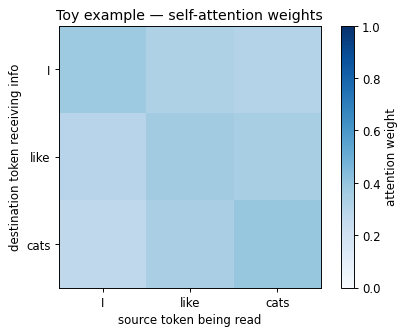

In [10]:
scores = Q @ K.T / np.sqrt(d_model)
weights = softmax(scores, axis=1)
attn_out = weights @ V

log("scores = Q @ K.T / sqrt(d)", np.round(scores, 3))
log("attention weights = row-wise softmax(scores)", np.round(weights, 3))
log("row sums (must be 1)", np.round(weights.sum(axis=1), 6))
log("attention output = weights @ V", np.round(attn_out, 3))
assert np.allclose(weights.sum(axis=1), 1.0)
assert attn_out.shape == (3, 4)

plt.imshow(weights, cmap="Blues", vmin=0, vmax=1)
plt.title("Toy example — self-attention weights")
plt.xticks(range(3), trace_tokens)
plt.yticks(range(3), trace_tokens)
plt.xlabel("source token being read")
plt.ylabel("destination token receiving info")
plt.colorbar(label="attention weight")
plt.show()

## Self-attention from scratch — Toy example: one row is a weighted average

For one destination token, the attention output is a weighted sum of the value vectors. This cell
prints every source token's contribution before adding them up.

[focus destination token] like
[its attention row] [0.295 0.363 0.342]
[contribution from I] [0.174 0.018 0.012 0.006]
[contribution from like] [0.04  0.167 0.058 0.036]
[contribution from cats] [0.014 0.068 0.202 0.041]
[sum of contributions] [0.227 0.253 0.272 0.083]
[attn_out row from matrix multiply] [0.227 0.253 0.272 0.083]


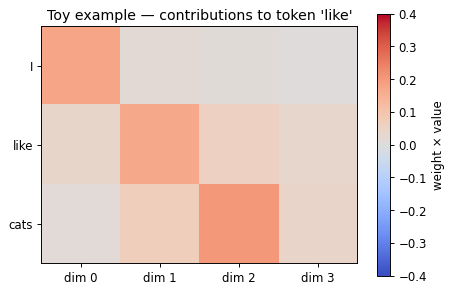

In [12]:
focus = 1  # "like"
contrib = weights[focus, :, None] * V
manual_sum = contrib.sum(axis=0)

log("focus destination token", trace_tokens[focus])
log("its attention row", np.round(weights[focus], 3))
for src, row in zip(trace_tokens, contrib):
    log(f"contribution from {src}", np.round(row, 3))
log("sum of contributions", np.round(manual_sum, 3))
log("attn_out row from matrix multiply", np.round(attn_out[focus], 3))
assert np.allclose(manual_sum, attn_out[focus])

plt.imshow(contrib, cmap="coolwarm", vmin=-0.4, vmax=0.4)
plt.title("Toy example — contributions to token 'like'")
plt.xticks(range(4), [f"dim {i}" for i in range(4)])
plt.yticks(range(3), trace_tokens)
plt.colorbar(label="weight × value")
plt.show()

## Self-attention from scratch — Toy example: why divide by $\sqrt{d}$

When vectors get wider, dot products can get large. Dividing by $\sqrt{d}$ keeps softmax from
becoming too sharp too early.

[raw scores for token 'I'] [0.566 0.27  0.182]
[raw softmax weights for token 'I'] [0.413 0.307 0.281]
[scaled scores for token 'I'] [0.283 0.135 0.091]
[scaled softmax weights for token 'I'] [0.372 0.321 0.307]


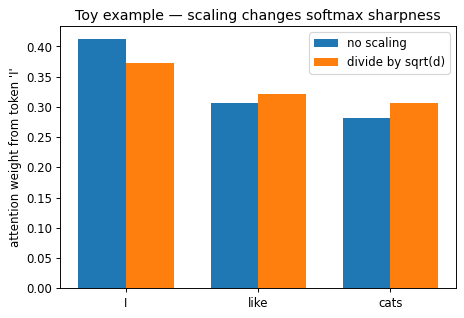

In [14]:
raw_scores = Q @ K.T
raw_weights = softmax(raw_scores, axis=1)
scaled_weights = softmax(raw_scores / np.sqrt(d_model), axis=1)

log("raw scores for token 'I'", np.round(raw_scores[0], 3))
log("raw softmax weights for token 'I'", np.round(raw_weights[0], 3))
log("scaled scores for token 'I'", np.round((raw_scores / np.sqrt(d_model))[0], 3))
log("scaled softmax weights for token 'I'", np.round(scaled_weights[0], 3))
assert np.allclose(raw_weights.sum(axis=1), 1.0)
assert np.allclose(scaled_weights.sum(axis=1), 1.0)

xpos = np.arange(len(trace_tokens))
plt.bar(xpos - 0.18, raw_weights[0], width=0.36, label="no scaling")
plt.bar(xpos + 0.18, scaled_weights[0], width=0.36, label="divide by sqrt(d)")
plt.title("Toy example — scaling changes softmax sharpness")
plt.xticks(xpos, trace_tokens)
plt.ylabel("attention weight from token 'I'")
plt.legend()
plt.show()

## 3 · Causal mask — Toy example: decoder-only attention cannot peek right

A language model predicts the **next** token. During training and generation, the vector at
position 0 must not read position 1 or 2, because those are future tokens. A **causal mask** sets
future scores to `-inf` before softmax, making their probabilities exactly 0.

**Good for:** honest next-token prediction and autoregressive generation.  
**Watch out for:** forgetting the mask leaks the answer during training.

[future_mask (True means blocked)] [[0 1 1]
 [0 0 1]
 [0 0 0]]
[masked scores (-inf above diagonal)] [[0.283      -inf    -inf]
 [0.1295  0.338      -inf]
 [0.07175 0.27925 0.42975]]
[masked attention weights] [[1.    0.    0.   ]
 [0.448 0.552 0.   ]
 [0.273 0.336 0.391]]
[row sums after masking] [1. 1. 1.]


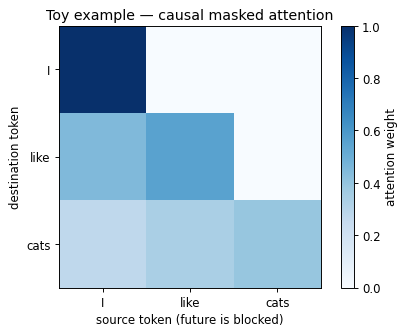

In [16]:
T = len(trace_tokens)
future_mask = np.triu(np.ones((T, T), dtype=bool), k=1)
masked_scores = scores.copy()
masked_scores[future_mask] = -np.inf
masked_weights = softmax(masked_scores, axis=1)
masked_out = masked_weights @ V

log("future_mask (True means blocked)", future_mask.astype(int))
log("masked scores (-inf above diagonal)", masked_scores)
log("masked attention weights", np.round(masked_weights, 3))
log("row sums after masking", np.round(masked_weights.sum(axis=1), 6))
assert np.allclose(masked_weights.sum(axis=1), 1.0)
assert np.allclose(masked_weights[np.triu_indices(T, k=1)], 0.0)

plt.imshow(masked_weights, cmap="Blues", vmin=0, vmax=1)
plt.title("Toy example — causal masked attention")
plt.xticks(range(T), trace_tokens)
plt.yticks(range(T), trace_tokens)
plt.xlabel("source token (future is blocked)")
plt.ylabel("destination token")
plt.colorbar(label="attention weight")
plt.show()

## Causal mask — Toy example: compare unmasked vs masked for the first token

The first token has no past. With a causal mask, it can only attend to itself.

[unmasked attention row for first token] [0.372 0.321 0.307]
[masked attention row for first token] [1. 0. 0.]
[unmasked output for first token] [0.267 0.231 0.247 0.076]
[masked output for first token] [0.59 0.06 0.04 0.02]


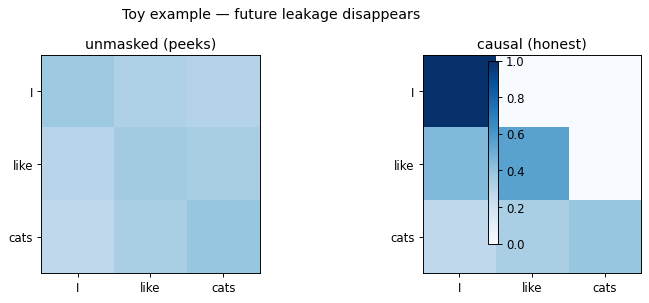

In [18]:
log("unmasked attention row for first token", np.round(weights[0], 3))
log("masked attention row for first token", np.round(masked_weights[0], 3))
log("unmasked output for first token", np.round(attn_out[0], 3))
log("masked output for first token", np.round(masked_out[0], 3))
assert np.allclose(masked_weights[0], np.array([1.0, 0.0, 0.0]))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
for a, mat, title in zip(ax, [weights, masked_weights], ["unmasked (peeks)", "causal (honest)"]):
    im = a.imshow(mat, cmap="Blues", vmin=0, vmax=1)
    a.set_title(title); a.set_xticks(range(T)); a.set_xticklabels(trace_tokens)
    a.set_yticks(range(T)); a.set_yticklabels(trace_tokens)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Toy example — future leakage disappears")
plt.tight_layout()
plt.show()

## 4 · Positional encoding — Toy example: sine/cosine order signal

Self-attention alone does not know whether `"I like cats"` or `"cats like I"` came first. A
**positional encoding (PE)** adds a small position-specific vector to each token embedding. Here we
use the classic sinusoidal version: sine on even dimensions, cosine on odd dimensions, base 10000.

**Good for:** injecting word order without changing token IDs.  
**Watch out for:** token meaning and position are added together, so the model must learn to use both.

[sinusoidal PE for 6 positions x 4 dims] [[ 0.     1.     0.     1.   ]
 [ 0.841  0.54   0.01   1.   ]
 [ 0.909 -0.416  0.02   1.   ]
 [ 0.141 -0.99   0.03   1.   ]
 [-0.757 -0.654  0.04   0.999]
 [-0.959  0.284  0.05   0.999]]


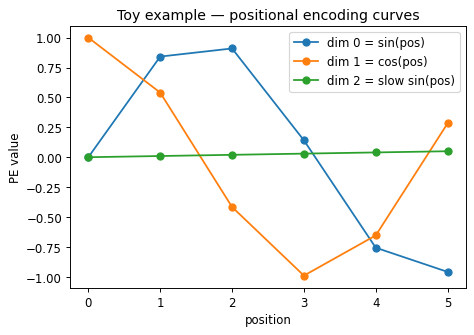

In [20]:
def sinusoidal_pe(n_positions, d_model, base=10000.0):
    pos = np.arange(n_positions)[:, None]
    div = np.exp(np.arange(0, d_model, 2) * (-np.log(base) / d_model))
    pe = np.zeros((n_positions, d_model))
    pe[:, 0::2] = np.sin(pos * div)
    pe[:, 1::2] = np.cos(pos * div)
    return pe

pe6 = sinusoidal_pe(6, d_model)
log("sinusoidal PE for 6 positions x 4 dims", np.round(pe6, 3))
assert pe6.shape == (6, 4)

plt.plot(pe6[:, 0], "-o", label="dim 0 = sin(pos)")
plt.plot(pe6[:, 1], "-o", label="dim 1 = cos(pos)")
plt.plot(pe6[:, 2], "-o", label="dim 2 = slow sin(pos)")
plt.title("Toy example — positional encoding curves")
plt.xlabel("position")
plt.ylabel("PE value")
plt.legend()
plt.show()

## Positional encoding — Toy example: add PE to token embeddings

The model sees `embedding[token_id] + positional_encoding[position]`, not the plain token embedding.

[token embeddings X_tok] [[ 0.2  0.   0.1  0.3]
 [ 0.9  0.1 -0.2  0. ]
 [ 0.1  0.8  0.2 -0.1]
 [-0.2  0.3  0.9  0.1]]
[position encodings for sentence] [[ 0.     1.     0.     1.   ]
 [ 0.841  0.54   0.01   1.   ]
 [ 0.909 -0.416  0.02   1.   ]
 [ 0.141 -0.99   0.03   1.   ]]
[X_with_pe = X_tok + PE] [[ 0.2    1.     0.1    1.3  ]
 [ 1.741  0.64  -0.19   1.   ]
 [ 1.009  0.384  0.22   0.9  ]
 [-0.059 -0.69   0.93   1.1  ]]


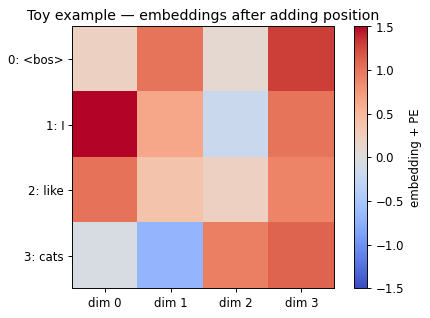

In [22]:
pe_sentence = sinusoidal_pe(len(sentence), d_model)
X_with_pe = X_tok + pe_sentence

log("token embeddings X_tok", np.round(X_tok, 3))
log("position encodings for sentence", np.round(pe_sentence, 3))
log("X_with_pe = X_tok + PE", np.round(X_with_pe, 3))
assert X_with_pe.shape == X_tok.shape

plt.imshow(X_with_pe, cmap="coolwarm", vmin=-1.5, vmax=1.5)
plt.title("Toy example — embeddings after adding position")
plt.xticks(range(4), [f"dim {i}" for i in range(4)])
plt.yticks(range(len(sentence)), [f"{i}: {w}" for i, w in enumerate(sentence)])
plt.colorbar(label="embedding + PE")
plt.show()

## Positional encoding — Toy example: the same word changes by position

Before PE, every `"cats"` row is identical. After PE, the same word at positions 0, 1, 2, and 3 has
different vectors, so order is visible.

[same token IDs] [3, 3, 3, 3]
[before PE (all rows equal)] [[-0.2  0.3  0.9  0.1]
 [-0.2  0.3  0.9  0.1]
 [-0.2  0.3  0.9  0.1]
 [-0.2  0.3  0.9  0.1]]
[after adding PE (rows differ)] [[-0.2    1.3    0.9    1.1  ]
 [ 0.641  0.84   0.91   1.1  ]
 [ 0.709 -0.116  0.92   1.1  ]
 [-0.059 -0.69   0.93   1.1  ]]


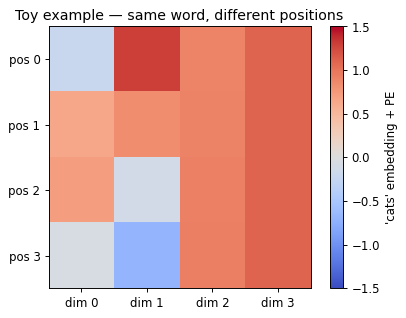

In [24]:
same_ids = np.array([vocab["cats"], vocab["cats"], vocab["cats"], vocab["cats"]])
same_before = E[same_ids]
same_after = same_before + sinusoidal_pe(len(same_ids), d_model)

log("same token IDs", same_ids.tolist())
log("before PE (all rows equal)", np.round(same_before, 3))
log("after adding PE (rows differ)", np.round(same_after, 3))
assert np.allclose(same_before[0], same_before[3])
assert not np.allclose(same_after[0], same_after[3])

plt.imshow(same_after, cmap="coolwarm", vmin=-1.5, vmax=1.5)
plt.title("Toy example — same word, different positions")
plt.xticks(range(4), [f"dim {i}" for i in range(4)])
plt.yticks(range(4), [f"pos {i}" for i in range(4)])
plt.colorbar(label="'cats' embedding + PE")
plt.show()

## 5 · Multi-head attention — Toy example: split 4 dims into 2 heads

**Multi-head attention** splits the model dimension into smaller heads. Each head runs attention
separately, then the outputs are concatenated. With `d_model=4` and `2` heads, each head sees
`d_head=2` dimensions.

**Good for:** letting different heads focus on different relationships.  
**Watch out for:** every head is tiny here for hand tracing; real models use many wider heads.

[head 0 Q slice] [[0.8  0.1 ]
 [0.2  0.75]
 [0.25 0.35]]
[head 0 attention weights] [[0.42  0.314 0.266]
 [0.301 0.387 0.312]
 [0.336 0.353 0.311]]
[head 0 output] [[0.293 0.223]
 [0.233 0.258]
 [0.249 0.245]]
[head 1 Q slice] [[0.25 0.05]
 [0.25 0.3 ]
 [0.8  0.25]]
[head 1 attention weights] [[0.305 0.33  0.366]
 [0.309 0.323 0.369]
 [0.246 0.313 0.441]]
[head 1 output] [[0.281 0.083]
 [0.281 0.083]
 [0.32  0.089]]


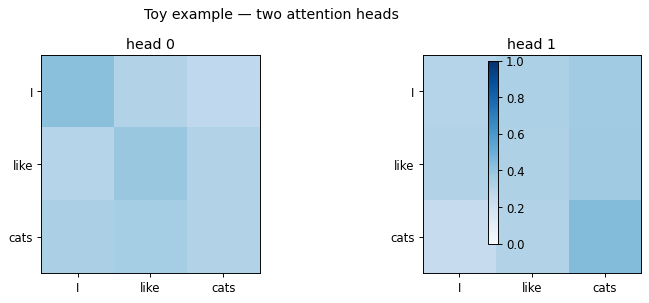

In [26]:
n_heads = 2
d_head = d_model // n_heads
head_outputs, head_weights = [], []
for h in range(n_heads):
    sl = slice(h * d_head, (h + 1) * d_head)
    Qh, Kh, Vh = Q[:, sl], K[:, sl], V[:, sl]
    sh = Qh @ Kh.T / np.sqrt(d_head)
    wh = softmax(sh, axis=1)
    oh = wh @ Vh
    head_weights.append(wh)
    head_outputs.append(oh)
    log(f"head {h} Q slice", np.round(Qh, 3))
    log(f"head {h} attention weights", np.round(wh, 3))
    log(f"head {h} output", np.round(oh, 3))
    assert np.allclose(wh.sum(axis=1), 1.0)
    assert oh.shape == (3, d_head)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
for h, a in enumerate(ax):
    im = a.imshow(head_weights[h], cmap="Blues", vmin=0, vmax=1)
    a.set_title(f"head {h}")
    a.set_xticks(range(3)); a.set_xticklabels(trace_tokens)
    a.set_yticks(range(3)); a.set_yticklabels(trace_tokens)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Toy example — two attention heads")
plt.tight_layout()
plt.show()

## Multi-head attention — Toy example: concatenate heads and project

After each head returns a small output, the Transformer concatenates them back to `d_model=4`.
An optional output projection mixes the heads.

[head output shapes] [(3, 2), (3, 2)]
[concatenated heads (3 x 4)] [[0.293 0.223 0.281 0.083]
 [0.233 0.258 0.281 0.083]
 [0.249 0.245 0.32  0.089]]
[Wo output projection] [[1.  0.  0.1 0. ]
 [0.  1.  0.  0.1]
 [0.1 0.  1.  0. ]
 [0.  0.1 0.  1. ]]
[multi-head output] [[0.321 0.231 0.31  0.105]
 [0.261 0.267 0.305 0.109]
 [0.281 0.254 0.345 0.114]]


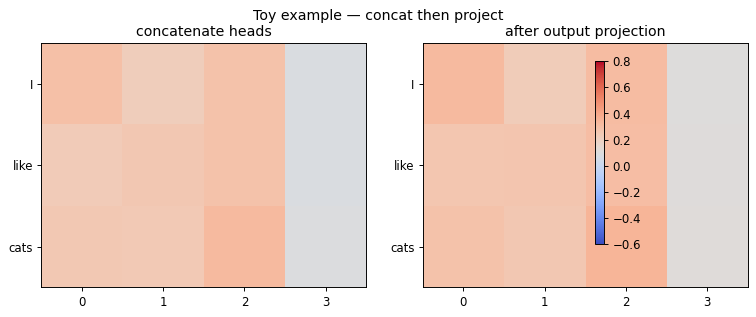

In [28]:
concat_heads = np.concatenate(head_outputs, axis=1)
Wo = np.array([[1.0, 0.0, 0.1, 0.0],
               [0.0, 1.0, 0.0, 0.1],
               [0.1, 0.0, 1.0, 0.0],
               [0.0, 0.1, 0.0, 1.0]])
mha_out = concat_heads @ Wo

log("head output shapes", [h.shape for h in head_outputs])
log("concatenated heads (3 x 4)", np.round(concat_heads, 3))
log("Wo output projection", np.round(Wo, 2))
log("multi-head output", np.round(mha_out, 3))
assert concat_heads.shape == (3, 4)
assert mha_out.shape == (3, 4)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
im0 = ax[0].imshow(concat_heads, cmap="coolwarm", vmin=-0.6, vmax=0.8)
ax[0].set_title("concatenate heads")
im1 = ax[1].imshow(mha_out, cmap="coolwarm", vmin=-0.6, vmax=0.8)
ax[1].set_title("after output projection")
for a in ax:
    a.set_xticks(range(4)); a.set_yticks(range(3)); a.set_yticklabels(trace_tokens)
fig.colorbar(im1, ax=ax, shrink=0.8)
plt.suptitle("Toy example — concat then project")
plt.tight_layout()
plt.show()

## Multi-head attention — Toy example: heads can disagree

Because each head sees different dimensions, its attention row can prefer different source tokens.

[destination token] cats
[head 0 attention row for 'cats'] [0.336 0.353 0.311]
[head 0 strongest source] like
[head 1 attention row for 'cats'] [0.246 0.313 0.441]
[head 1 strongest source] cats


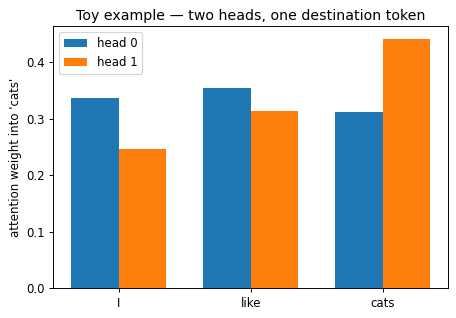

In [30]:
focus = 2  # destination token "cats"
log("destination token", trace_tokens[focus])
for h, wh in enumerate(head_weights):
    log(f"head {h} attention row for 'cats'", np.round(wh[focus], 3))
    log(f"head {h} strongest source", trace_tokens[int(np.argmax(wh[focus]))])
assert all(np.allclose(wh.sum(axis=1), 1.0) for wh in head_weights)

xpos = np.arange(len(trace_tokens))
plt.bar(xpos - 0.18, head_weights[0][focus], width=0.36, label="head 0")
plt.bar(xpos + 0.18, head_weights[1][focus], width=0.36, label="head 1")
plt.title("Toy example — two heads, one destination token")
plt.xticks(xpos, trace_tokens)
plt.ylabel("attention weight into 'cats'")
plt.legend()
plt.show()

## 6 · Feed-forward network (FFN / MLP) — Toy example: expand then shrink

After attention, each token passes through the same small neural network: expand from `4 → 8`,
apply a nonlinearity, then shrink from `8 → 4`. This is often called an **MLP** or **FFN**.

**Good for:** transforming each token's features after it has gathered context.  
**Watch out for:** the FFN does not mix tokens with each other; attention already did that.

[FFN input = mha_out] [[0.321 0.231 0.31  0.105]
 [0.261 0.267 0.305 0.109]
 [0.281 0.254 0.345 0.114]]
[hidden_pre = input @ W1 + b1 (3 x 8)] [[ 0.396 -0.003  0.303  0.284 -0.075  0.125  0.005 -0.008]
 [ 0.343  0.032  0.283  0.302 -0.112  0.156  0.    -0.031]
 [ 0.369  0.022  0.314  0.289 -0.099  0.163 -0.011 -0.012]]
[hidden_relu = max(0, hidden_pre)] [[0.396 0.    0.303 0.284 0.    0.125 0.005 0.   ]
 [0.343 0.032 0.283 0.302 0.    0.156 0.    0.   ]
 [0.369 0.022 0.314 0.289 0.    0.163 0.    0.   ]]
[ffn_out = hidden_relu @ W2 + b2 (3 x 4)] [[0.106 0.028 0.163 0.253]
 [0.088 0.051 0.171 0.243]
 [0.091 0.052 0.179 0.244]]


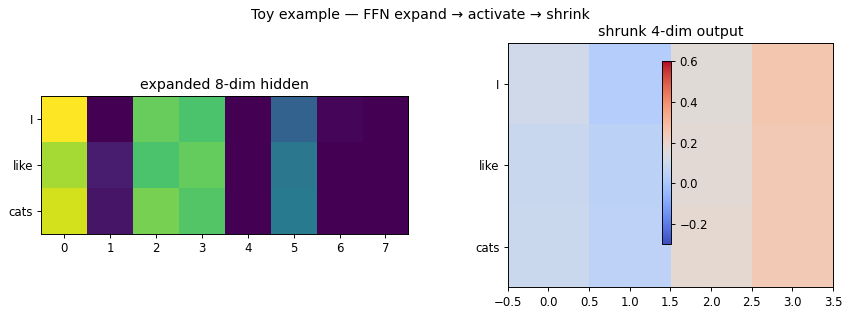

In [32]:
W1 = np.array([[ 0.8, -0.2,  0.3,  0.0,  0.5, -0.4,  0.2,  0.1],
               [-0.1,  0.7,  0.0,  0.4, -0.2,  0.3,  0.1, -0.5],
               [ 0.2,  0.1,  0.6, -0.3,  0.0,  0.5, -0.4,  0.2],
               [ 0.0, -0.3,  0.2,  0.8,  0.1, -0.2,  0.4,  0.6]])
b1 = np.array([0.10, -0.10, 0.00, 0.20, -0.20, 0.05, 0.00, -0.05])
W2 = np.array([[ 0.4,  0.0, -0.1,  0.2],
               [ 0.1,  0.5,  0.0, -0.2],
               [-0.2,  0.1,  0.4,  0.0],
               [ 0.0, -0.1,  0.2,  0.5],
               [ 0.3,  0.0,  0.1, -0.1],
               [-0.1,  0.3,  0.2,  0.0],
               [ 0.2, -0.2,  0.0,  0.3],
               [ 0.0,  0.2, -0.3,  0.4]])
b2 = np.array([0.02, -0.01, 0.00, 0.03])

hidden_pre = mha_out @ W1 + b1
hidden_relu = np.maximum(0, hidden_pre)
ffn_out = hidden_relu @ W2 + b2

log("FFN input = mha_out", np.round(mha_out, 3))
log("hidden_pre = input @ W1 + b1 (3 x 8)", np.round(hidden_pre, 3))
log("hidden_relu = max(0, hidden_pre)", np.round(hidden_relu, 3))
log("ffn_out = hidden_relu @ W2 + b2 (3 x 4)", np.round(ffn_out, 3))
assert hidden_pre.shape == (3, 8)
assert ffn_out.shape == (3, 4)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
im0 = ax[0].imshow(hidden_relu, cmap="viridis")
ax[0].set_title("expanded 8-dim hidden")
im1 = ax[1].imshow(ffn_out, cmap="coolwarm", vmin=-0.3, vmax=0.6)
ax[1].set_title("shrunk 4-dim output")
for a in ax:
    a.set_yticks(range(3)); a.set_yticklabels(trace_tokens)
fig.colorbar(im1, ax=ax, shrink=0.8)
plt.suptitle("Toy example — FFN expand → activate → shrink")
plt.tight_layout()
plt.show()

## Feed-forward network — Toy example: token-by-token independence

The same FFN is applied to each row separately. If we change token 0, token 1 and token 2 outputs
do not change inside the FFN.

[change added only to token 0] [ 0.5 -0.2  0.1  0.3]
[FFN output difference for all tokens] [[ 0.239902  0.012826 -0.013006  0.31317 ]
 [ 0.        0.        0.        0.      ]
 [ 0.        0.        0.        0.      ]]
[tokens 1 and 2 unchanged?] True


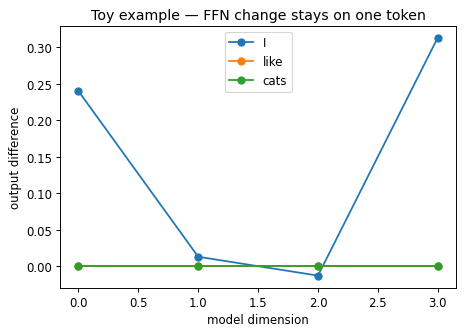

In [34]:
changed = mha_out.copy()
changed[0] += np.array([0.5, -0.2, 0.1, 0.3])
changed_hidden = np.maximum(0, changed @ W1 + b1)
changed_out = changed_hidden @ W2 + b2
diff = changed_out - ffn_out

log("change added only to token 0", np.round(changed[0] - mha_out[0], 3))
log("FFN output difference for all tokens", np.round(diff, 6))
log("tokens 1 and 2 unchanged?", bool(np.allclose(diff[1:], 0.0)))
assert not np.allclose(diff[0], 0.0)
assert np.allclose(diff[1:], 0.0)

plt.plot(diff.T, marker="o")
plt.title("Toy example — FFN change stays on one token")
plt.xlabel("model dimension")
plt.ylabel("output difference")
plt.legend(trace_tokens)
plt.show()

## 7 · GELU vs ReLU — Toy example: two nonlinearities

A **nonlinearity** lets a neural network bend instead of being one big linear matrix. **ReLU** is
`max(0, x)`. **GELU** is smoother near 0 and is used by GPT-2-style Transformers.

**Good for:** adding expressive power between the two FFN matrices.  
**Watch out for:** GELU and ReLU are similar for big positive values but behave differently near 0.

[columns: x, ReLU(x), GELU(x)] [[-2.     0.    -0.045]
 [-1.     0.    -0.159]
 [ 0.     0.     0.   ]
 [ 1.     1.     0.841]
 [ 2.     2.     1.955]]
[GELU is smooth near zero] negative inputs are softened, not hard-clipped


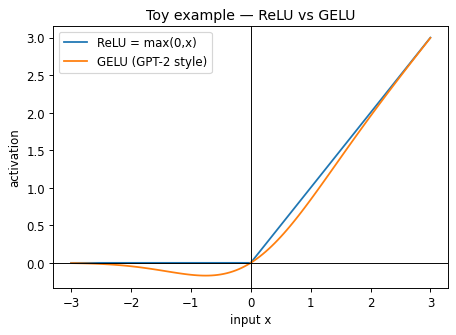

In [36]:
def gelu(z):
    z = np.asarray(z, dtype=float)
    return 0.5 * z * (1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z**3)))

xs = np.linspace(-3, 3, 121)
relu = np.maximum(0, xs)
gelu_vals = gelu(xs)
table_x = np.array([-2., -1., 0., 1., 2.])
table = np.c_[table_x, np.maximum(0, table_x), gelu(table_x)]

log("columns: x, ReLU(x), GELU(x)", np.round(table, 3))
log("GELU is smooth near zero", "negative inputs are softened, not hard-clipped")
assert np.allclose(np.maximum(0, np.array([-1.0, 2.0])), np.array([0.0, 2.0]))
assert abs(gelu(0.0)) < 1e-12

plt.plot(xs, relu, label="ReLU = max(0,x)")
plt.plot(xs, gelu_vals, label="GELU (GPT-2 style)")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Toy example — ReLU vs GELU")
plt.xlabel("input x")
plt.ylabel("activation")
plt.legend()
plt.show()

## 8 · Residual connection — Toy example: add the sublayer back to x

A **residual connection** adds the input back after a sublayer: `x + sublayer(x)`. This gives the
model an easy path to keep old information while adding new information.

**Good for:** stable deep networks and preserving useful signals.  
**Watch out for:** residuals can grow in scale, so Transformers usually pair them with LayerNorm.

[x before residual] [[ 0.9    1.1   -0.2    1.   ]
 [ 0.941  1.34   0.21   0.9  ]
 [ 0.709 -0.116  0.92   1.1  ]]
[sublayer(x) toy = 0.5 * mha_out] [[0.16  0.116 0.155 0.053]
 [0.13  0.133 0.152 0.054]
 [0.141 0.127 0.172 0.057]]
[x + sublayer(x)] [[ 1.06   1.216 -0.045  1.053]
 [ 1.072  1.474  0.362  0.954]
 [ 0.85   0.011  1.092  1.157]]


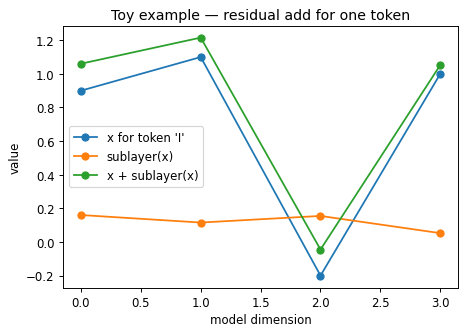

In [38]:
x_res = X + sinusoidal_pe(len(trace_tokens), d_model)
sublayer_toy = 0.5 * mha_out
residual_added = x_res + sublayer_toy

log("x before residual", np.round(x_res, 3))
log("sublayer(x) toy = 0.5 * mha_out", np.round(sublayer_toy, 3))
log("x + sublayer(x)", np.round(residual_added, 3))
assert residual_added.shape == x_res.shape

plt.plot(x_res[0], "-o", label="x for token 'I'")
plt.plot(sublayer_toy[0], "-o", label="sublayer(x)")
plt.plot(residual_added[0], "-o", label="x + sublayer(x)")
plt.title("Toy example — residual add for one token")
plt.xlabel("model dimension")
plt.ylabel("value")
plt.legend()
plt.show()

## LayerNorm — Toy example: normalize each token row

**LayerNorm** normalizes across the features of one token vector. For each row, it subtracts that
row's mean and divides by that row's standard deviation, so the row has mean 0 and standard
deviation 1.

[row means before] [0.821 0.966 0.777]
[row stds before] [0.504 0.398 0.457]
[LayerNorm output] [[ 0.475  0.783 -1.718  0.46 ]
 [ 0.267  1.277 -1.516 -0.028]
 [ 0.159 -1.677  0.689  0.829]]
[row means after (≈0)] [ 0. -0.  0.]
[row stds after (≈1)] [1. 1. 1.]


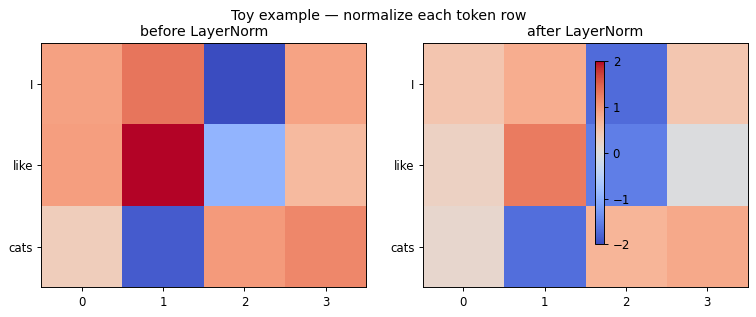

In [40]:
def layer_norm(x, eps=1e-8):
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    y = (x - mean) / (std + eps)
    return y, mean, std

normed, row_mean_before, row_std_before = layer_norm(residual_added)
row_mean_after = normed.mean(axis=1)
row_std_after = normed.std(axis=1)

log("row means before", np.round(row_mean_before.ravel(), 3))
log("row stds before", np.round(row_std_before.ravel(), 3))
log("LayerNorm output", np.round(normed, 3))
log("row means after (≈0)", np.round(row_mean_after, 6))
log("row stds after (≈1)", np.round(row_std_after, 6))
assert np.allclose(row_mean_after, 0.0, atol=1e-6)
assert np.allclose(row_std_after, 1.0, atol=1e-6)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
im0 = ax[0].imshow(residual_added, cmap="coolwarm")
ax[0].set_title("before LayerNorm")
im1 = ax[1].imshow(normed, cmap="coolwarm", vmin=-2, vmax=2)
ax[1].set_title("after LayerNorm")
for a in ax:
    a.set_xticks(range(4)); a.set_yticks(range(3)); a.set_yticklabels(trace_tokens)
fig.colorbar(im1, ax=ax, shrink=0.8)
plt.suptitle("Toy example — normalize each token row")
plt.tight_layout()
plt.show()

## 9 · Put it together — Toy example: one decoder block

A decoder-only Transformer block is:

1. **Masked multi-head attention**
2. **Add & LayerNorm**
3. **FFN / MLP**
4. **Add & LayerNorm**

**Good for:** turning token history into better next-token features.  
**Watch out for:** the mask must be inside every attention layer.

[block input x_block0] [[ 0.9    1.1   -0.2    1.   ]
 [ 0.941  1.34   0.21   0.9  ]
 [ 0.709 -0.116  0.92   1.1  ]]
[masked MHA sublayer output] [[0.594 0.942 0.099 0.906]
 [0.677 1.016 0.265 0.907]
 [0.705 0.825 0.555 0.803]]
[FFN sublayer output] [[ 0.201 -0.415  0.233  0.975]
 [ 0.165 -0.245  0.213  0.776]
 [ 0.152  0.141 -0.29   0.867]]
[block output after add&norm twice] [[ 0.125  0.149 -1.538  1.263]
 [ 0.017  0.697 -1.633  0.92 ]
 [ 0.021 -1.303 -0.219  1.501]]


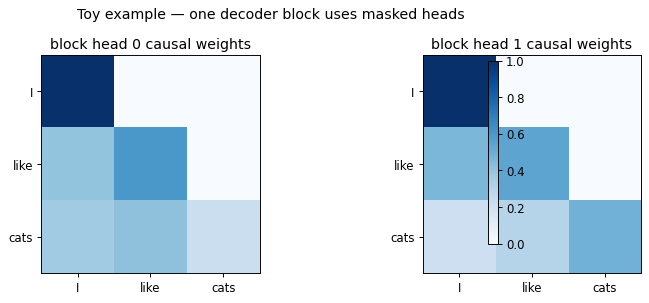

In [42]:
def masked_multi_head(x):
    Qb, Kb, Vb = x @ Wq, x @ Wk, x @ Wv
    all_weights, all_outputs = [], []
    Tlocal = x.shape[0]
    mask = np.triu(np.ones((Tlocal, Tlocal), dtype=bool), k=1)
    for h in range(n_heads):
        sl = slice(h * d_head, (h + 1) * d_head)
        scores_h = Qb[:, sl] @ Kb[:, sl].T / np.sqrt(d_head)
        scores_h[mask] = -np.inf
        weights_h = softmax(scores_h, axis=1)
        out_h = weights_h @ Vb[:, sl]
        all_weights.append(weights_h)
        all_outputs.append(out_h)
    concat = np.concatenate(all_outputs, axis=1)
    return concat @ Wo, all_weights

def ffn_gelu(x):
    return gelu(x @ W1 + b1) @ W2 + b2

def transformer_block(x):
    attn_part, attn_weights = masked_multi_head(x)
    after_attn, _, _ = layer_norm(x + attn_part)
    ffn_part = ffn_gelu(after_attn)
    after_ffn, _, _ = layer_norm(after_attn + ffn_part)
    return after_ffn, attn_weights, attn_part, ffn_part

x_block0 = X + sinusoidal_pe(len(trace_tokens), d_model)
block1, block1_weights, block1_attn, block1_ffn = transformer_block(x_block0)

log("block input x_block0", np.round(x_block0, 3))
log("masked MHA sublayer output", np.round(block1_attn, 3))
log("FFN sublayer output", np.round(block1_ffn, 3))
log("block output after add&norm twice", np.round(block1, 3))
assert block1.shape == x_block0.shape
for wh in block1_weights:
    assert np.allclose(wh[np.triu_indices(len(trace_tokens), k=1)], 0.0)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
for h, a in enumerate(ax):
    im = a.imshow(block1_weights[h], cmap="Blues", vmin=0, vmax=1)
    a.set_title(f"block head {h} causal weights")
    a.set_xticks(range(3)); a.set_xticklabels(trace_tokens)
    a.set_yticks(range(3)); a.set_yticklabels(trace_tokens)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle("Toy example — one decoder block uses masked heads")
plt.tight_layout()
plt.show()

## Put it together — Toy example: stack 2 decoder blocks

Real decoder-only Transformers stack many blocks. We stack 2 tiny blocks with shared toy weights so
the shape story stays simple.

[shape ledger] {'input': (3, 4), 'after block 1': (3, 4), 'after block 2': (3, 4)}
[block2 masked MHA output] [[-0.325  0.421 -1.074  0.822]
 [-0.387  0.575 -1.118  0.796]
 [-0.232  0.104 -0.765  0.71 ]]
[block2 output] [[-0.147 -0.301 -1.152  1.6  ]
 [-0.253  0.03  -1.287  1.51 ]
 [-0.158 -0.827 -0.692  1.677]]
[per-token norms: rows=input, block1, block2] [[1.749 1.881 1.604]
 [2.    2.    2.   ]
 [2.    2.    2.   ]]


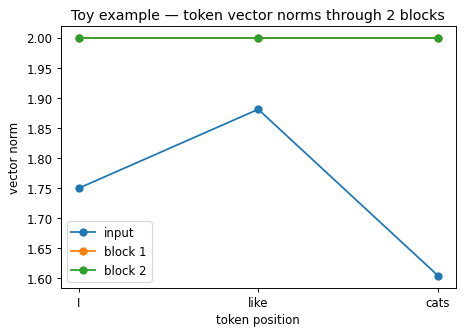

In [44]:
block2, block2_weights, block2_attn, block2_ffn = transformer_block(block1)
shape_ledger = {
    "input": x_block0.shape,
    "after block 1": block1.shape,
    "after block 2": block2.shape,
}
norms = np.vstack([
    np.linalg.norm(x_block0, axis=1),
    np.linalg.norm(block1, axis=1),
    np.linalg.norm(block2, axis=1),
])

log("shape ledger", shape_ledger)
log("block2 masked MHA output", np.round(block2_attn, 3))
log("block2 output", np.round(block2, 3))
log("per-token norms: rows=input, block1, block2", np.round(norms, 3))
assert block2.shape == (3, 4)
assert all(np.allclose(wh[np.triu_indices(3, k=1)], 0.0) for wh in block2_weights)

plt.plot(norms.T, marker="o")
plt.title("Toy example — token vector norms through 2 blocks")
plt.xlabel("token position")
plt.ylabel("vector norm")
plt.xticks(range(3), trace_tokens)
plt.legend(["input", "block 1", "block 2"])
plt.show()

## Put it together — Toy example: unembedding to vocab logits

To predict the next token, the model takes the final vector at the last position and multiplies by
an **unembedding** matrix to get one score, called a **logit**, for every vocabulary token. Softmax
turns logits into a probability distribution.

[last hidden vector (last token position)] [-0.158 -0.827 -0.692  1.677]
[vocab logits] {'<bos>': 0.402, 'I': -0.005, 'like': -0.954, 'cats': -0.569, 'dogs': -0.946, '.': 1.27}
[next-token probabilities] {'<bos>': 0.202, 'I': 0.135, 'like': 0.052, 'cats': 0.077, 'dogs': 0.053, '.': 0.482}
[greedy next token ID] 5 = .


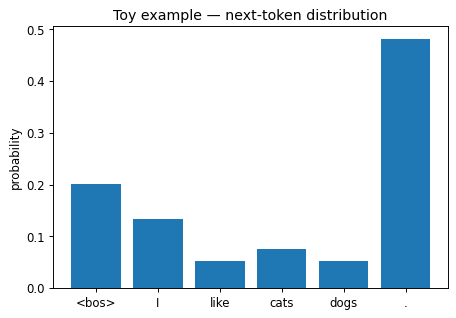

In [46]:
U = np.array([[ 0.2,  0.7,  0.1, -0.2, -0.1,  0.0],
              [ 0.0,  0.1,  0.8,  0.2,  0.1, -0.2],
              [ 0.1, -0.2,  0.2,  0.9,  0.8,  0.1],
              [ 0.3,  0.0, -0.1,  0.1, -0.2,  0.7]])
ub = np.array([0.0, 0.05, 0.03, 0.02, 0.01, 0.0])
last_vector = block2[-1]
logits = last_vector @ U + ub
probs = softmax(logits, axis=0)
next_id = int(np.argmax(probs))

log("last hidden vector (last token position)", np.round(last_vector, 3))
log("vocab logits", {id_to_word[i]: round(float(logits[i]), 3) for i in range(len(vocab))})
log("next-token probabilities", {id_to_word[i]: round(float(probs[i]), 3) for i in range(len(vocab))})
log("greedy next token ID", f"{next_id} = {id_to_word[next_id]}")
assert logits.shape == (len(vocab),)
assert np.allclose(probs.sum(), 1.0)

plt.bar(range(len(vocab)), probs)
plt.title("Toy example — next-token distribution")
plt.xticks(range(len(vocab)), [id_to_word[i] for i in range(len(vocab))])
plt.ylabel("probability")
plt.show()

## Put it together — Toy example: autoregressive generation loop

**Autoregressive** means "use previous outputs as future inputs." The model consumes token IDs,
embeds them, predicts the **next** ID, appends it, and repeats.

[step 0 prompt IDs] [0, 1]
[step 0 prompt tokens] ['<bos>', 'I']
[step 0 next probs] {'<bos>': 0.213, 'I': 0.29, 'like': 0.062, 'cats': 0.043, 'dogs': 0.038, '.': 0.355}
[step 0 append] 5 = .
[step 1 prompt IDs] [0, 1, 5]
[step 1 prompt tokens] ['<bos>', 'I', '.']
[step 1 next probs] {'<bos>': 0.209, 'I': 0.174, 'like': 0.054, 'cats': 0.062, 'dogs': 0.046, '.': 0.455}
[step 1 append] 5 = .
[step 2 prompt IDs] [0, 1, 5, 5]
[step 2 prompt tokens] ['<bos>', 'I', '.', '.']
[step 2 next probs] {'<bos>': 0.203, 'I': 0.136, 'like': 0.054, 'cats': 0.076, 'dogs': 0.052, '.': 0.481}
[step 2 append] 5 = .
[step 3 prompt IDs] [0, 1, 5, 5, 5]
[step 3 prompt tokens] ['<bos>', 'I', '.', '.', '.']
[step 3 next probs] {'<bos>': 0.192, 'I': 0.1, 'like': 0.061, 'cats': 0.1, 'dogs': 0.062, '.': 0.486}
[step 3 append] 5 = .
[step 4 prompt IDs] [0, 1, 5, 5, 5, 5]
[step 4 prompt tokens] ['<bos>', 'I', '.', '.', '.', '.']
[step 4 next probs] {'<bos>': 0.185, 'I': 0.086, 'like': 0.072, 'cats': 0.117, 'dogs': 0

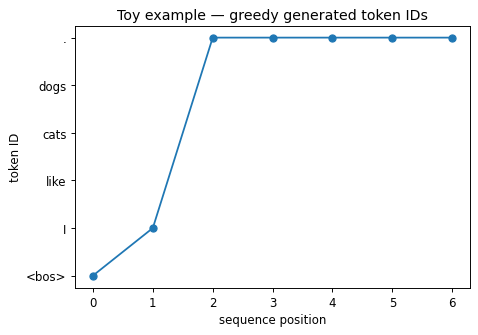

In [48]:
def forward_ids(token_ids):
    token_ids = np.array(token_ids, dtype=int)
    x = E[token_ids] + sinusoidal_pe(len(token_ids), d_model)
    h1, _, _, _ = transformer_block(x)
    h2, _, _, _ = transformer_block(h1)
    logits_local = h2[-1] @ U + ub
    probs_local = softmax(logits_local, axis=0)
    return logits_local, probs_local

generated = [vocab["<bos>"], vocab["I"]]
history_probs = []
for step in range(5):
    logits_step, probs_step = forward_ids(generated)
    next_step_id = int(np.argmax(probs_step))
    history_probs.append(probs_step)
    log(f"step {step} prompt IDs", generated)
    log(f"step {step} prompt tokens", [id_to_word[i] for i in generated])
    log(f"step {step} next probs", {id_to_word[i]: round(float(probs_step[i]), 3) for i in range(len(vocab))})
    log(f"step {step} append", f"{next_step_id} = {id_to_word[next_step_id]}")
    generated.append(next_step_id)

log("generated ID sequence", generated)
log("generated token sequence", [id_to_word[i] for i in generated])
assert len(generated) == 7
assert all(0 <= i < len(vocab) for i in generated)

plt.plot(generated, marker="o")
plt.title("Toy example — greedy generated token IDs")
plt.xlabel("sequence position")
plt.ylabel("token ID")
plt.yticks(range(len(vocab)), [id_to_word[i] for i in range(len(vocab))])
plt.show()

## Plain-English pseudocode — decoder-only forward + generate loop

```text
given prompt token IDs:
  repeat until enough new tokens:
    1. look up token embeddings
    2. add positional encodings
    3. for each decoder block:
         masked multi-head self-attention
         add residual connection and LayerNorm
         feed-forward network
         add residual connection and LayerNorm
    4. take the final vector at the last position
    5. unembed to vocab logits
    6. softmax logits into next-token probabilities
    7. sample or choose the largest-probability next ID
    8. append that ID to the prompt
```

[token IDs] (3,)
[embed] (3, 4)
[+ PE] (3, 4)
[block 1] (3, 4)
[block 2] (3, 4)
[unembed logits] (6,)
[softmax probs] (6,)
[probability sum] 1.0


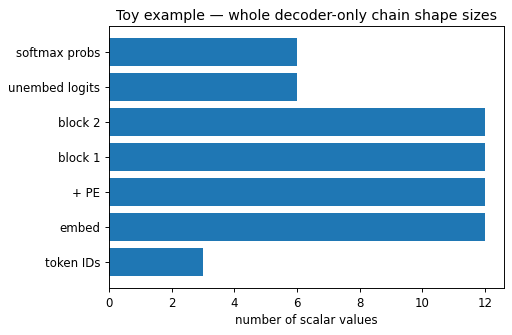

In [50]:
ledger_ids = [vocab["<bos>"], vocab["I"], vocab["like"]]
ledger_embed = E[ledger_ids]
ledger_pe = sinusoidal_pe(len(ledger_ids), d_model)
ledger_x = ledger_embed + ledger_pe
ledger_b1, _, _, _ = transformer_block(ledger_x)
ledger_b2, _, _, _ = transformer_block(ledger_b1)
ledger_logits = ledger_b2[-1] @ U + ub
ledger_probs = softmax(ledger_logits, axis=0)

flow = [
    ("token IDs", np.shape(ledger_ids)),
    ("embed", ledger_embed.shape),
    ("+ PE", ledger_x.shape),
    ("block 1", ledger_b1.shape),
    ("block 2", ledger_b2.shape),
    ("unembed logits", ledger_logits.shape),
    ("softmax probs", ledger_probs.shape),
]
for name, shape in flow:
    log(name, shape)
log("probability sum", round(float(ledger_probs.sum()), 6))
assert np.allclose(ledger_probs.sum(), 1.0)

heights = [len(ledger_ids), ledger_embed.size, ledger_x.size, ledger_b1.size, ledger_b2.size, ledger_logits.size, ledger_probs.size]
plt.barh([name for name, _ in flow], heights)
plt.title("Toy example — whole decoder-only chain shape sizes")
plt.xlabel("number of scalar values")
plt.show()

## Recap — whole module as one chain

Decoder-only Transformers do this loop:

**tokens → embed (+ positional encoding) → [masked attention → FFN] × N → unembed → next-token softmax → sample/argmax → append → repeat**

Key takeaways:
- Token IDs become vectors through an embedding lookup.
- Self-attention uses `QKᵀ / sqrt(d)` then softmax, and each row sums to 1.
- A causal mask zeros the upper triangle so future tokens cannot be read.
- Positional encodings inject order.
- Multi-head attention lets small heads look at different relationships.
- FFNs transform each token row after attention mixes context.
- Residual connections preserve information; LayerNorm stabilizes scale.
- Generation is just next-token prediction repeated on the growing ID sequence.